# Day 5: Week 1 Mini_Notebook
This notebook continues the vehicle data analysis from Day4 it uses Pandas to load and clean the data, Numpy to calculate a new feature, and Matplotlib to visualize the results.

# Task 1: Load and Clean the Dataset
The vehicle dataset is loaded into a Pandas DataFrame. The columns needed for this analysis for thi analysis are selected. and rows with missing values are removed before creating the plots.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("day4/exp1_14drivers_14cars_dailyRoutes.csv" , low_memory=False)
col = ["MARK" , "MODEL" , "CAR_YEAR" , "SPEED" ,"ENGINE_COOLANT_TEMP" , "ENGINE_RPM" , "AIR_INTAKE_TEMP"]
cars = df[col].copy()
print("Dataset shape before cleaning:", cars.shape)
print("\nMissing values before cleaning:")
print(cars.isnull().sum())

cars = cars.dropna()

print("\nDataset shape after cleaning:",cars.shape)
print(cars.head())


Dataset shape before cleaning: (47514, 7)

Missing values before cleaning:
MARK                      55
MODEL                     55
CAR_YEAR                  55
SPEED                    985
ENGINE_COOLANT_TEMP    13550
ENGINE_RPM             13655
AIR_INTAKE_TEMP        13162
dtype: int64

Dataset shape after cleaning: (32603, 7)
        MARK  MODEL  CAR_YEAR  SPEED  ENGINE_COOLANT_TEMP  ENGINE_RPM  \
0  chevrolet  agile    2011.0    0.0                 80.0      1009.0   
1  chevrolet  agile    2011.0    0.0                 80.0      1003.0   
2  chevrolet  agile    2011.0    0.0                 80.0       995.0   
3  chevrolet  agile    2011.0    0.0                 80.0      1004.0   
4  chevrolet  agile    2011.0    0.0                 80.0      1005.0   

   AIR_INTAKE_TEMP  
0             59.0  
1             59.0  
2             59.0  
3             60.0  
4             60.0  


Task 2: Calculate a New Feature with NumPy
 the speed valus are converted from kilometers per hour to meters per second using NumPy. The mean speed is also calcultaed to provide a simple summary of the cleaned data.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("day4/exp1_14drivers_14cars_dailyRoutes.csv" , low_memory=False)
col = ["MARK" , "MODEL" , "CAR_YEAR" , "SPEED" ,"ENGINE_COOLANT_TEMP" , "ENGINE_RPM" , "AIR_INTAKE_TEMP"]
cars = df[col].copy()

cars = cars.dropna()


speed_values = cars["SPEED"].to_numpy()
cars["SPEED_M_S"] = np.round(speed_values / 3.6 , 2)

mean_speed = np.mean(speed_values)
max_speed = np.max(speed_values)

print(f"Mean Speed: {mean_speed:.2f} km/h")
print(f"Maximum Speed: {max_speed:.2f} km/h")



Mean Speed: 34.46 km/h
Maximum Speed: 143.00 km/h


# Task 3: Visualize the Data

Four plots are plaved in one figure using subplots, Each plot shows the data from a different point of view. 

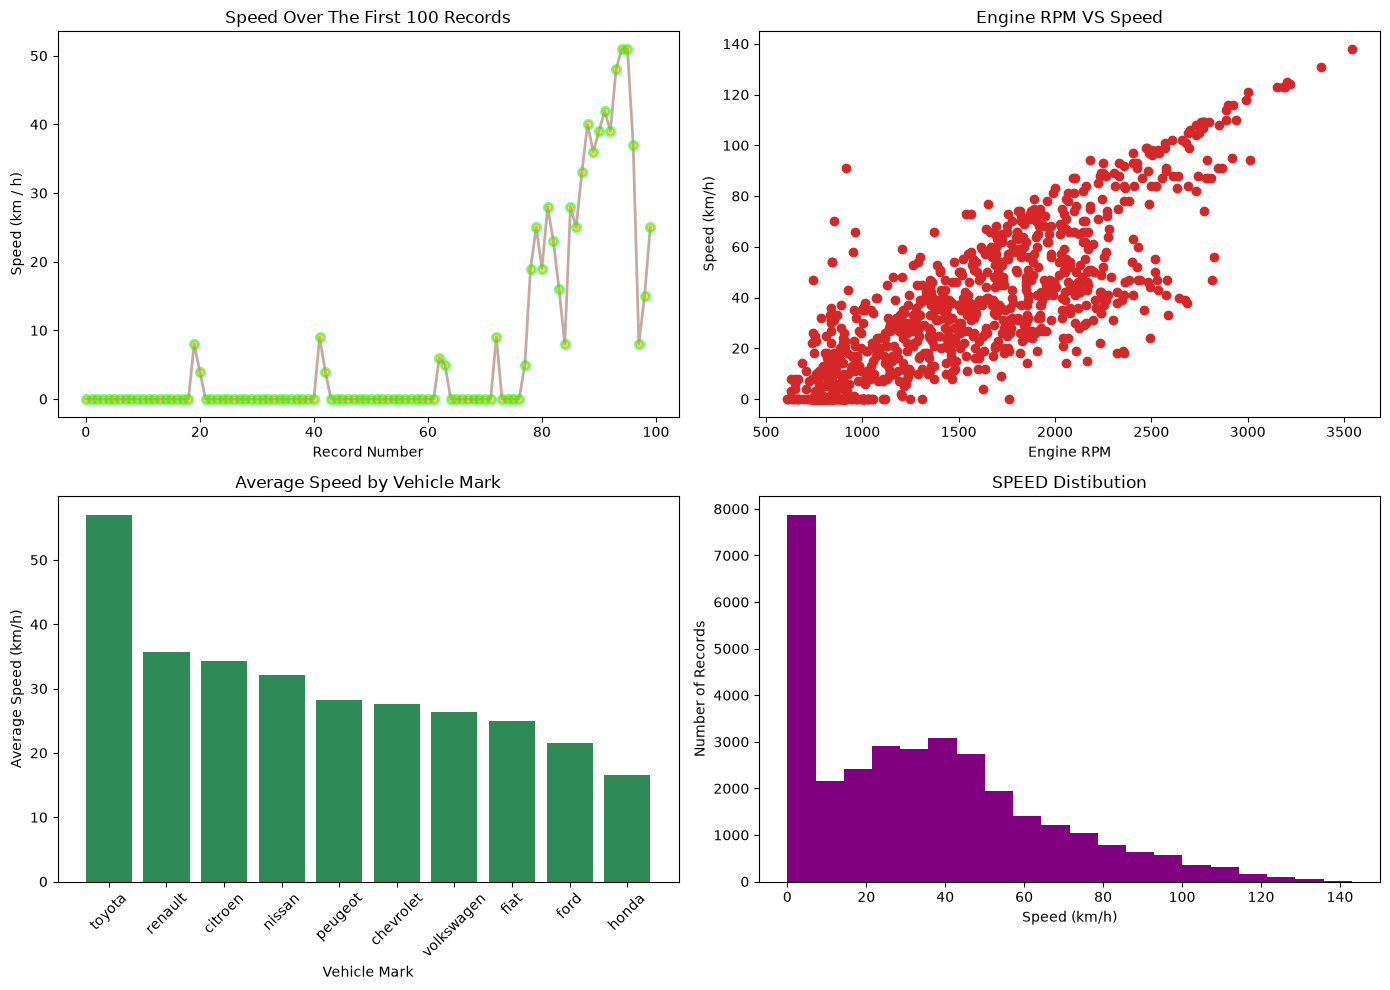

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("day4/exp1_14drivers_14cars_dailyRoutes.csv" , low_memory=False)
col = ["MARK" , "MODEL" , "CAR_YEAR" , "SPEED" ,"ENGINE_COOLANT_TEMP" , "ENGINE_RPM" , "AIR_INTAKE_TEMP"]
cars = df[col].copy()

cars = cars.dropna()


speed_values = cars["SPEED"].to_numpy()
cars["SPEED_M_S"] = np.round(speed_values / 3.6 , 2)

mean_speed = np.mean(speed_values)
max_speed = np.max(speed_values)

sample = cars.sample(n=min(1000 , len(cars)),random_state=42)
average_speed_by_mark = cars.groupby("MARK")["SPEED"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(cars['SPEED'].head(100) ,marker='o',c='tab:brown' ,lw='2', ls='-' ,mfc='orange' , mec='lime', mew='2' , alpha=.5)
axes[0,0].set_title("Speed Over The First 100 Records")
axes[0,0].set_xlabel("Record Number")
axes[0,0].set_ylabel("Speed (km / h)")

axes[0,1].scatter(sample["ENGINE_RPM"] , sample["SPEED"] , color='tab:red')
axes[0,1].set_title("Engine RPM VS Speed")
axes[0,1].set_xlabel("Engine RPM")
axes[0,1].set_ylabel("Speed (km/h)")


axes[1 , 0].bar(average_speed_by_mark.index , average_speed_by_mark.values , color="seagreen")
axes[1,0].set_title("Average Speed by Vehicle Mark")
axes[1,0].set_xlabel("Vehicle Mark")
axes[1,0].set_ylabel("Average Speed (km/h)")
axes[1,0].tick_params(axis='x', rotation=45)

axes[1 , 1].hist(cars["SPEED"],bins=20,color="purple")
axes[1,1].set_title("SPEED Distibution")
axes[1,1].set_xlabel("Speed (km/h)")
axes[1,1].set_ylabel("Number of Records")

plt.tight_layout()
plt.show()

# Results
- The line plot shows how the vehicle speed changes across the first 100 records.
- The scatter plot shows that higher RPM values are generally connected with higher speeds, but the relationship is not identical for every record.
- The bar plot compares the average recorded speed for each vehicle mark n the dataset.
- The historgram shows that many speed records are close to zero. which mav represent stops or idle periods.

# Conclusion
This mim_notebook combined the main tools learned during week 1. NumPy was used for a numerical calculation, Pandas was used to load and clean the dataset, and Matplotlib was used to explore and communicate the results.
